In [54]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [55]:
import quantstream as qs
import os
import xarray as xr
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import plotly.graph_objects as go

import sys

import dotenv


dotenv.load_dotenv("../.env")

sys.path.append("../")

FMP_API_KEY = os.getenv("FMP_API_KEY")

In [56]:
fmp = qs.FMP_Connector(FMP_API_KEY)
data = fmp.get_intraday(
    symbol="NVDA",
    time_delta="5min",
    from_date="2023-02-01",
    to_date="2023-02-02",
)

/Users/christianl/repos/quantstream/quantstream/connectors/findataset.py:65: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can be silenced by converting the values to nanosecond precision ahead of time.
  col: xr.DataArray(raw_data[col], dims="time", coords={"time": index})
/Users/christianl/repos/quantstream/quantstream/connectors/findataset.py:65: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta6

In [57]:
data

<xarray.FinDataset> Size: 7kB
Dimensions:  (time: 156)
Coordinates:
  * time     (time) datetime64[ns] 1kB 2023-02-02T15:55:00 ... 2023-02-01T09:...
Data variables:
    open     (time) float64 1kB 21.66 21.51 21.5 21.51 ... 19.81 19.66 19.69
    low      (time) float64 1kB 21.62 21.5 21.47 21.45 ... 19.79 19.65 19.61
    high     (time) float64 1kB 21.75 21.67 21.53 21.56 ... 19.89 19.87 19.88
    close    (time) float64 1kB 21.72 21.66 21.5 21.5 ... 19.79 19.81 19.67
    volume   (time) int64 1kB 1499358 911354 424926 ... 1244523 1444246 1818253
Attributes:
    time_delta:  5min
    from_date:   2023-02-01
    to_date:     2023-02-02

In [58]:
df = data.to_dataframe()
df

,open,low,high,close,volume
time,,,,,
2023-02-02 15:55:00,21.65500,21.625,21.7460,21.72400,1499358
2023-02-02 15:50:00,21.50800,21.504,21.6710,21.65800,911354
2023-02-02 15:45:00,21.50200,21.466,21.5290,21.50300,424926
2023-02-02 15:40:00,21.51100,21.454,21.5568,21.50300,485702
2023-02-02 15:35:00,21.52800,21.496,21.5880,21.50900,638841
...,...,...,...,...,...
2023-02-01 09:50:00,19.87564,19.862,20.0100,20.00301,1570235
2023-02-01 09:45:00,19.79866,19.770,19.8950,19.87600,1012631
2023-02-01 09:40:00,19.81000,19.787,19.8900,19.79301,1244523


In [59]:
data_intraday = fmp.get_intraday(
    symbol="AAPL",
    time_delta="5min",
    from_date="2023-02-01",
    to_date="2023-02-02",
)
data_intraday.to_dataframe()

/Users/christianl/repos/quantstream/quantstream/connectors/findataset.py:65: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can be silenced by converting the values to nanosecond precision ahead of time.
  col: xr.DataArray(raw_data[col], dims="time", coords={"time": index})
/Users/christianl/repos/quantstream/quantstream/connectors/findataset.py:65: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta6

,open,low,high,close,volume
time,,,,,
2023-02-02 15:55:00,150.2100,150.1100,150.920,150.9200,3521530
2023-02-02 15:50:00,149.7000,149.7000,150.230,150.2200,2216696
2023-02-02 15:45:00,149.6700,149.4600,149.910,149.6950,1243864
2023-02-02 15:40:00,150.0700,149.6547,150.130,149.6600,1223690
2023-02-02 15:35:00,150.1900,149.9500,150.320,150.0650,1427698
...,...,...,...,...,...
2023-02-01 09:50:00,142.6150,142.5900,143.230,142.9900,1074525
2023-02-01 09:45:00,142.9597,142.5900,143.125,142.6268,995520
2023-02-01 09:40:00,142.9000,142.8500,143.300,142.9401,1039108


<Axes: xlabel='time'>

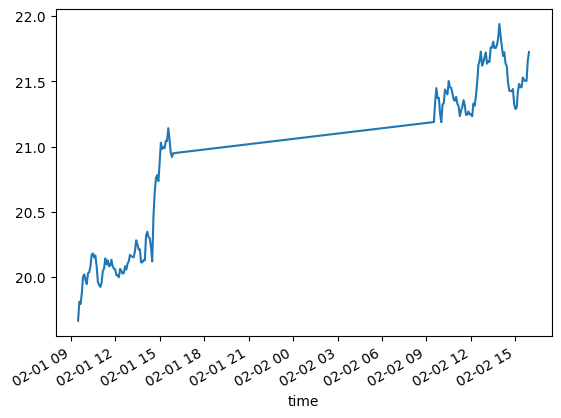

In [60]:
df["close"].plot()

In [61]:
portfolio = qs.Portfolio()
portfolio.add_security("NVDA")
portfolio.add_security("AAPL")
portfolio.add_security("TSLA")
portfolio.add_security("AMZN")

/Users/christianl/repos/quantstream/quantstream/connectors/findataset.py:65: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can be silenced by converting the values to nanosecond precision ahead of time.
  col: xr.DataArray(raw_data[col], dims="time", coords={"time": index})
/Users/christianl/repos/quantstream/quantstream/connectors/findataset.py:65: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta6

In [62]:
ds = portfolio.data['adjClose']

In [63]:
df = ds.to_dataframe()

In [64]:
# put securities as columns
df = df.unstack(level=0)

In [65]:
# drop the multiindex
df.columns = df.columns.droplevel()

<Axes: xlabel='time'>

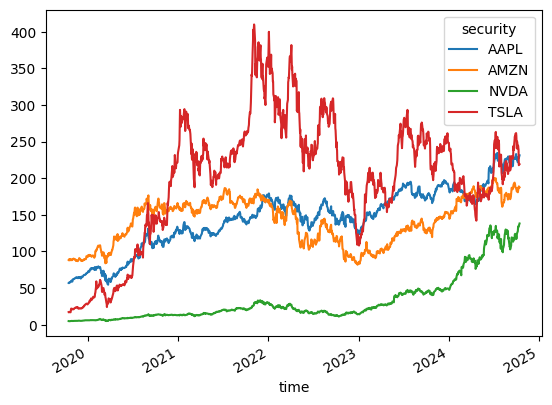

In [66]:
df.plot()

In [67]:
df

security,AAPL,AMZN,NVDA,TSLA
time,,,,
2019-10-15,56.93,88.37,4.89,17.19
2019-10-16,56.70,88.87,4.83,17.32
2019-10-17,56.92,89.37,4.83,17.46
2019-10-18,57.19,87.88,4.74,17.13
2019-10-21,58.18,89.28,4.88,16.90
...,...,...,...,...
2024-10-08,225.77,182.72,132.89,244.50
2024-10-09,229.54,185.17,132.65,241.05
2024-10-10,229.04,186.65,134.81,238.77


In [68]:
def generate_timeseries_json(df):
    json_data = {}
    for column in df.columns:
        json_data[column] = []
        for timestamp, value in df[column].iteritems():
            json_data[column].append({
                "timestamp": timestamp.isoformat(),
                "value": value
            })
    return json_data

 ### Changes Over Time

 - absolute changes
 - percentage change
 - log returns

In [69]:
vals = ds.values

In [70]:
df

security,AAPL,AMZN,NVDA,TSLA
time,,,,
2019-10-15,56.93,88.37,4.89,17.19
2019-10-16,56.70,88.87,4.83,17.32
2019-10-17,56.92,89.37,4.83,17.46
2019-10-18,57.19,87.88,4.74,17.13
2019-10-21,58.18,89.28,4.88,16.90
...,...,...,...,...
2024-10-08,225.77,182.72,132.89,244.50
2024-10-09,229.54,185.17,132.65,241.05
2024-10-10,229.04,186.65,134.81,238.77


In [75]:
# convert to dataframe
df.diff()

security,AAPL,AMZN,NVDA,TSLA
time,,,,
2019-10-15,NaN,NaN,NaN,NaN
2019-10-16,-0.23,0.50,-0.06,0.13
2019-10-17,0.22,0.50,0.00,0.14
2019-10-18,0.27,-1.49,-0.09,-0.33
2019-10-21,0.99,1.40,0.14,-0.23
...,...,...,...,...
2024-10-08,4.08,1.92,5.17,3.67
2024-10-09,3.77,2.45,-0.24,-3.45
2024-10-10,-0.50,1.48,2.16,-2.28


<Axes: xlabel='time'>

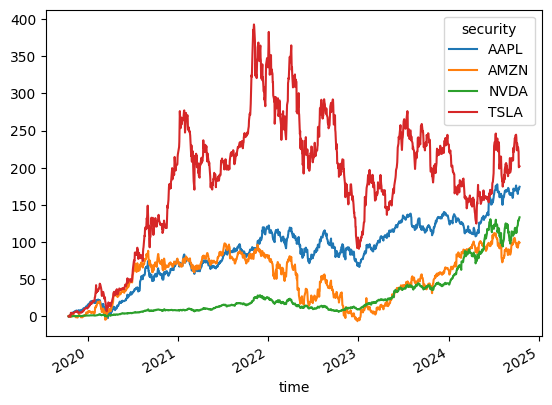

In [81]:
df.diff().cumsum().plot()

<Axes: xlabel='time'>

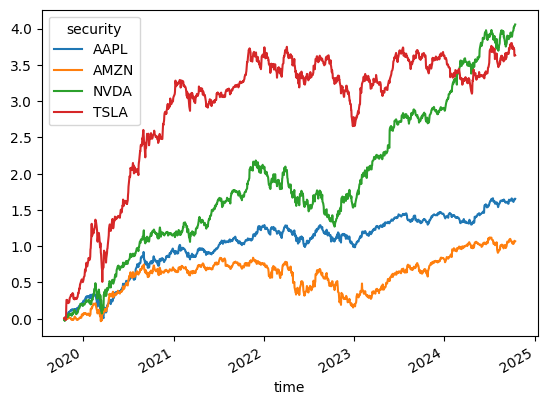

In [82]:
df.pct_change().cumsum().plot()

<Axes: xlabel='time'>

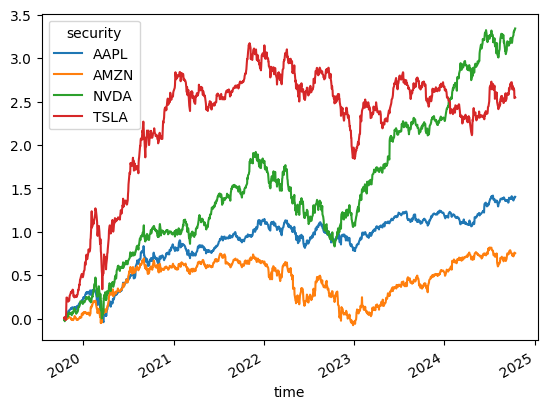

In [84]:
log_rets = np.log(df / df.shift(1))
log_rets.cumsum().plot()

<Axes: xlabel='time'>

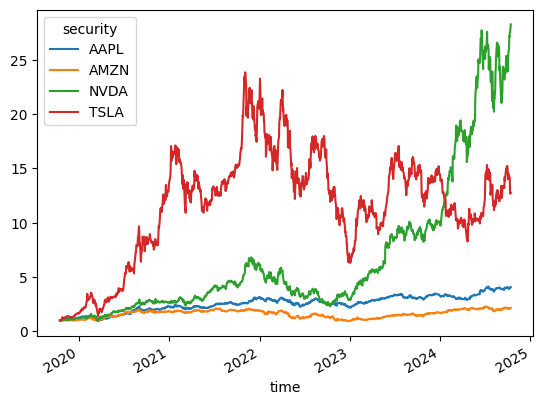

In [85]:
log_rets.cumsum().apply(np.exp).plot()